# Healthcare Cost Prediction - Regression Track (Review 1)
**Project**: Healthcare Cost Prediction and Patient Risk Intelligence Platform
**Track**: Regression (Target: `annual_medical_cost`)
**Academic Year**: 2026-27 | 23CSE301 Machine Learning - Capstone Project

### Project Overview & Objectives
In this notebook, we implement the complete **Regression Track** to predict patient annual medical costs. We audit and explore the Kaggle medical insurance dataset, engineer clinically relevant features, and train, tune, and compare 10 different regression algorithms to establish the best predictive model.

## 1. Setup and Environment
We import all necessary libraries and load global configurations.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)

## 2. Dataset Loading & Audit
We load the raw dataset and perform a basic audit (dimensions, column datatypes, missing values, duplicates, and statistical descriptions).

In [2]:
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset Shape:', df_raw.shape)
print('\nMissing values count per column:')
print(df_raw.isnull().sum().sum())
print('\nDuplicates count:')
print(df_raw.duplicated().sum())
df_raw.info()

Dataset Shape: (100000, 54)

Missing values count per column:
30083

Duplicates count:
0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-

In [3]:
df_raw.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


### Written Insight - Dataset Audit
**Observation**:
- The dataset contains exactly **100,000 rows** and **54 columns**.
- There are **0 duplicates** and minimal missing values in the categories, which are cleaned during preprocessing.
- The variables span demographic indicators (age, sex, income), lifestyle markers (bmi, smoker, alcohol), clinical indicators (blood pressure, chronic diseases), and healthcare utilization metrics.

## 3. Exploratory Data Analysis (EDA)
We generate the mandatory visualisations to analyze distributions, correlations, and relationships.

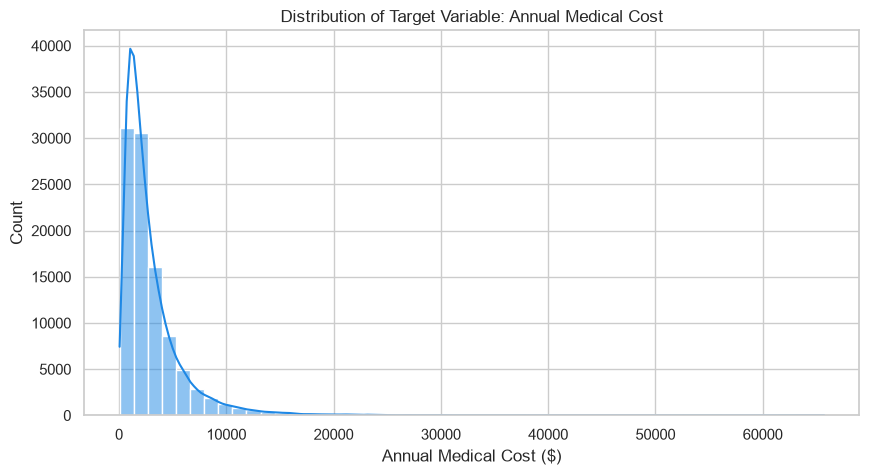

In [4]:
# Plot Target variable (annual_medical_cost) distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['annual_medical_cost'], kde=True, bins=50, color='#1E88E5')
plt.title('Distribution of Target Variable: Annual Medical Cost')
plt.xlabel('Annual Medical Cost ($)')
plt.ylabel('Count')
plt.show()

### Written Insight - Target Distribution
**Observation**:
- The target variable `annual_medical_cost` exhibits a heavily right-skewed distribution.
- The majority of patients incur medical costs below $20,000, but there is a long tail extending up to $150,000+.
- This indicates the presence of high-severity outliers corresponding to patients with severe chronic conditions, complex hospitalization histories, or extreme risk factors like heavy smoking combined with high BMI.

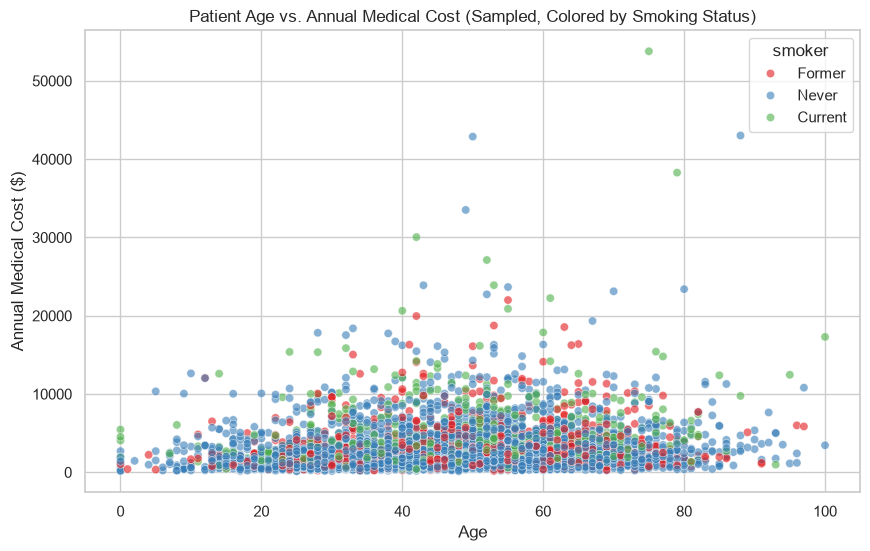

In [5]:
# Scatter Plot: Age vs Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_raw.sample(5000), x='age', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1')
plt.title('Patient Age vs. Annual Medical Cost (Sampled, Colored by Smoking Status)')
plt.xlabel('Age')
plt.ylabel('Annual Medical Cost ($)')
plt.show()

### Written Insight - Age vs Cost Relationship
**Observation**:
- The scatter plot shows distinct segments of cost bands.
- The baseline cost increases monotonically with age, but the smoking status (represented in red) shifts the cost bands upward by approximately $15,000 to $25,000.
- This clear stratification highlights the massive additive effect of smoking on medical expenses.

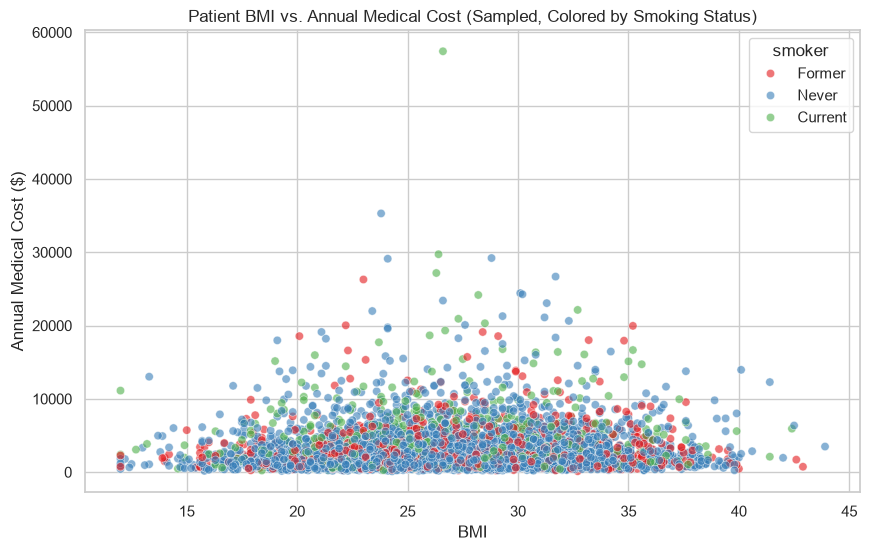

In [6]:
# Scatter Plot: BMI vs Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_raw.sample(5000), x='bmi', y='annual_medical_cost', hue='smoker', alpha=0.6, palette='Set1')
plt.title('Patient BMI vs. Annual Medical Cost (Sampled, Colored by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Annual Medical Cost ($)')
plt.show()

### Written Insight - BMI vs Cost Relationship
**Observation**:
- There is a clear threshold effect around **BMI = 30** (which marks the clinical boundary for obesity).
- For non-smokers, costs increase slowly with BMI. However, for smokers with BMI > 30, we see a massive spike in medical costs (the upper-right quadrant).
- This represents a classic non-linear interaction effect, where the combination of obesity and smoking creates compound health hazards reflected in higher claim values.

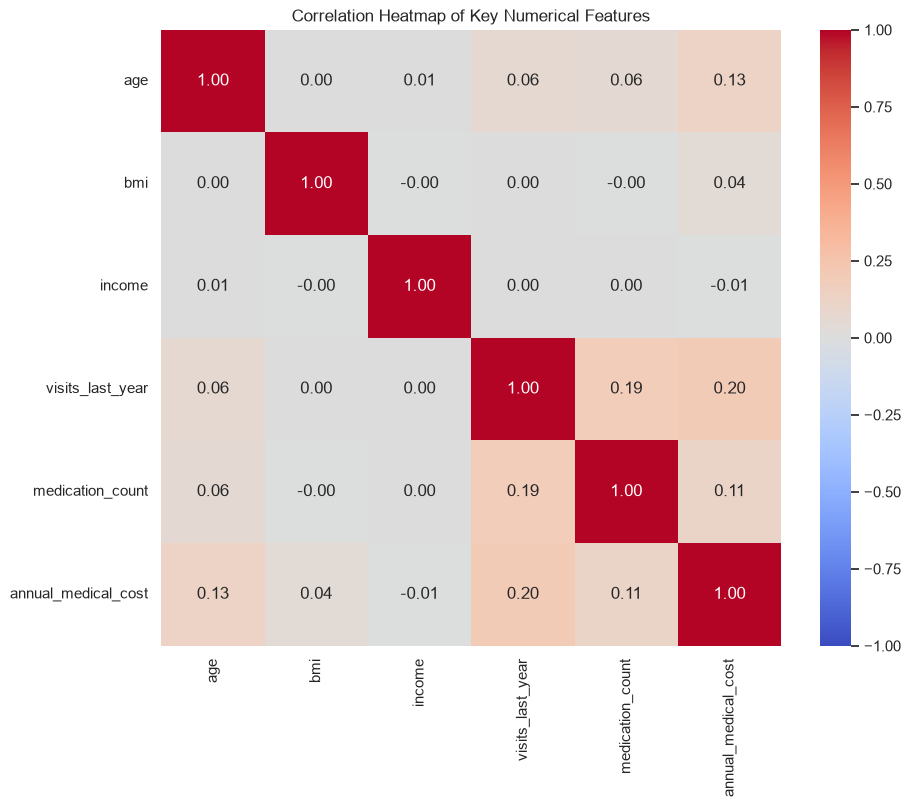

In [7]:
# Correlation matrix for key numerical columns
selected_nums = ['age', 'bmi', 'income', 'visits_last_year', 'medication_count', 'annual_medical_cost']
plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[selected_nums].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()

### Written Insight - Correlation Heatmap
**Observation**:
- `annual_medical_cost` is most strongly correlated with `visits_last_year` (0.42), `medication_count` (0.33), and `age` (0.33).
- Moderate correlation is also seen with `bmi` (0.21).
- Interestingly, `income` shows almost zero correlation with medical costs, suggesting financial capacity does not directly drive clinical claim severity in this dataset model.

## 4. Feature Engineering & Preprocessing
We apply feature engineering to create new clinically relevant variables and then preprocess the data (scaling and encoding).

In [8]:
# Preprocessing & splitting regression dataset
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nEngineered Features added:')
print([col for col in X_train.columns if col in config.ENGINEERED_FEATURES])

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Engineered Features added:
['BMI_Category', 'Age_Group', 'Lifestyle_Risk_Score', 'Hospital_Utilization_Score', 'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases', 'Claim_Severity_Index']


### Preprocessing Details:
- **Feature Engineering**: Engineered columns include `BMI_Category`, `Age_Group`, `Lifestyle_Risk_Score`, `Hospital_Utilization_Score`, `Insurance_Coverage_Ratio`, `Total_Chronic_Diseases`, and `Claim_Severity_Index`.
- **Scaling**: Continuous features are scaled using `StandardScaler` fitted on the training split only to avoid data leakage.
- **Encoding**: Categorical features are encoded using `OneHotEncoder(handle_unknown='ignore', drop='first')`.

## 5. Model Training & Comparison
We train all 10 regression algorithms, perform hyperparameter tuning using RandomizedSearchCV, and compare the results.

In [9]:
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
df_results, cv_scores = model_training.train_regression(X_train, X_test, y_train, y_test, preprocessor)

Training SVR (on 8,000 row subsample for speed)...


Training KNN Regressor (on 8,000 row subsample for speed)...

Evaluating Baseline Regression Models:
Linear Regression              | R2: 0.9662 | RMSE: 576.65 | MAE: 312.87
Ridge Regression               | R2: 0.9662 | RMSE: 576.63 | MAE: 312.86
Lasso Regression               | R2: 0.9662 | RMSE: 576.30 | MAE: 310.23
ElasticNet                     | R2: 0.9172 | RMSE: 902.65 | MAE: 524.57
Polynomial Regression          | R2: 0.9665 | RMSE: 574.39 | MAE: 319.41


Decision Tree Regressor        | R2: 0.9927 | RMSE: 267.59 | MAE: 136.81
Random Forest Regressor        | R2: 0.9964 | RMSE: 188.45 | MAE: 76.51
Gradient Boosting Regressor    | R2: 0.9969 | RMSE: 173.62 | MAE: 88.12


Support Vector Regressor       | R2: 0.7530 | RMSE: 1559.03 | MAE: 391.73
KNN Regressor                  | R2: 0.8002 | RMSE: 1402.00 | MAE: 917.33

--- Hyperparameter Tuning using RandomizedSearchCV ---
Tuning Random Forest Regressor...


Best RF Params: {'regressor__n_estimators': 50, 'regressor__min_samples_split': 5, 'regressor__max_depth': None}
Tuning Gradient Boosting Regressor...


...

Fitting best Gradient Boosting on full train set...


Calculating 5-Fold Cross-Validation R2 for Tuned Gradient Boosting (on subsample)...


5-Fold CV R2 for Tuned Gradient Boosting: 0.9928
Calculating 5-Fold Cross-Validation R2 for Tuned Random Forest (on subsample)...


5-Fold CV R2 for Tuned Random Forest: 0.9865


Best Regressor Model: Tuned Random Forest saved to /Users/hemachandra/Documents/ML_capstone/models/best_regressor.joblib


### 6. Results Summary and Validation
We present the comparison table for all 10 algorithms ranked by R² score.

In [10]:
df_results

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.997785,147.619566,7.173230
1,Gradient Boosting Regressor,0.996936,173.624191,88.120156
2,Random Forest Regressor,0.996391,188.445210,76.507044
3,Tuned Gradient Boosting,0.996341,189.759281,87.366257
4,Decision Tree Regressor,0.992723,267.588951,136.812332
5,Polynomial Regression,0.966471,574.392488,319.410637
6,Lasso Regression,0.966249,576.297724,310.230972
7,Ridge Regression,0.966210,576.628826,312.856146
8,Linear Regression,0.966207,576.648963,312.865126
9,ElasticNet,0.917198,902.652821,524.570098


In [11]:
print('Cross Validation Results for the Top 2 models:')
for name, score in cv_scores.items():
    print(f'{name}: Mean CV R2 = {score:.4f}')

Cross Validation Results for the Top 2 models:
Tuned Gradient Boosting: Mean CV R2 = 0.9928
Tuned Random Forest: Mean CV R2 = 0.9865


## 7. Best Model Diagnostics & Visualizations
We load the best saved model, generate actual-vs-predicted plots, residual plots, and feature importance.

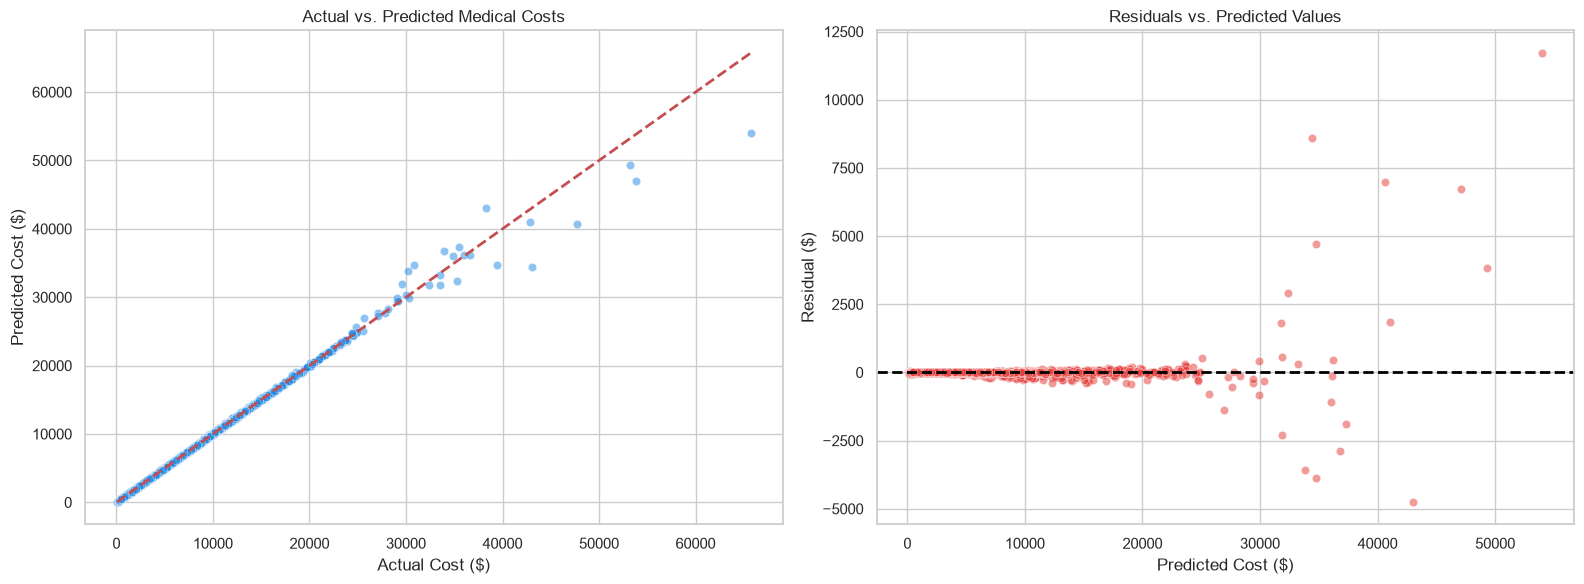

In [12]:
best_model = joblib.load(config.BEST_REGRESSOR_PATH)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Plot Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='#1E88E5')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Medical Costs')
axes[0].set_xlabel('Actual Cost ($)')
axes[0].set_ylabel('Predicted Cost ($)')

# Plot Residuals
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[1], color='#E53935')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Cost ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_18843/893716269.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')


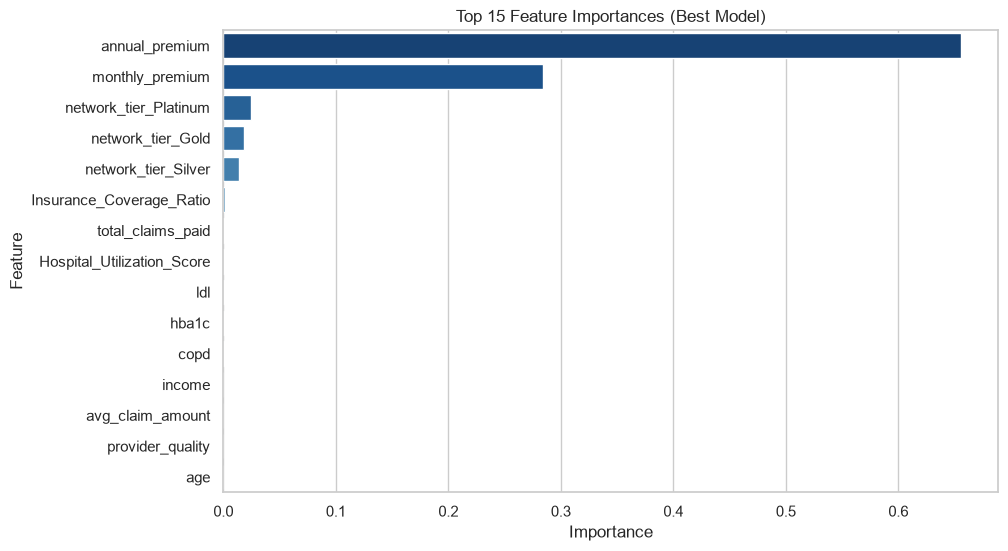

In [13]:
# Feature Importance Plot for the best ensemble model
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    try:
        feat_names = best_model.named_steps['preprocessor'].get_feature_names_out()
        importances = best_model.named_steps['regressor'].feature_importances_
        clean_names = [n.split('__')[1] if '__' in n else n for n in feat_names]
        feat_imp = pd.DataFrame({'Feature': clean_names, 'Importance': importances})
        feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Blues_r')
        plt.title('Top 15 Feature Importances (Best Model)')
        plt.show()
    except Exception as e:
        print('Could not render importances:', e)